In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

base = "/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/"

dsera5 = xr.open_dataset(base+'global_era5_1980_2022_6h-128x64_equiangular_with_poles_conservative/fields.zarr')
ds = xr.open_dataset(base+"global_nextgems_1990_2020_6h-128x64_try2/fields.zarr")
ds_2t_conservative = xr.open_dataset('/hkfs/work/workspace/scratch/xo8179-nextgems_regridded/try2/3D_nextgems_1990_2020_6hourly_128x64_surface_2t_bilinear.zarr')


In [2]:
test = xr.open_dataset('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_2049/not_regridded/2D_nextgems_2049_6hourly_0.25deg_tp.nc')
print(test)

<xarray.Dataset> Size: 12GB
Dimensions:  (time: 1460, value: 1038240)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2049-01-01 ... 2049-12-31T18:00:00
    lon      (value) float64 8MB ...
    lat      (value) float64 8MB ...
Dimensions without coordinates: value
Data variables:
    tp       (time, value) float64 12GB ...
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...


In [3]:
def find_max(ds):
    import xarray as xr

    # Find the maximum value
    maximum = ds.max()

    # Find the indices of the maximum value
    # First flatten, then use argmax
    flat_index = np.argmax(ds.values)

    # Convert flat index back to multidimensional indices (time, lon, lat)
    time_idx, lon_idx, lat_idx = np.unravel_index(flat_index, ds.shape)

    # Extract coordinates
    lat = float(ds.latitude[lat_idx].values)
    lon = float(ds.longitude[lon_idx].values)
    time = str(ds.time[time_idx].values)

    print(f"Max temperature: {float(maximum.values):.2f} K")
    print(f"At indices: time={time_idx}, lon_idx={lon_idx}, lat_idx={lat_idx}")
    print(f"At location: lat={lat}, lon={lon}, time={time}")

In [4]:
ds_conservative = xr.open_dataset('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_try2_conservative/fields.zarr')
ds_mixed = xr.open_dataset('/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_try2/fields.zarr')

In [6]:
print('Temperature max at 850 - conservative')
find_max(ds_conservative["temperature"].sel(level=850))
print('')
print('Temperature max at 850 - mixed')
find_max(ds_mixed["temperature"].sel(level=850))
print('')
print('Temperature max at 2m - mixed')
find_max(ds_conservative["2m_temperature"])
print('')
print('Temperature max at 2m - mixed')
find_max(ds_mixed["2m_temperature"])

Temperature max at 850 - conservative
Max temperature: 315.59 K
At indices: time=29950, lon_idx=29, lat_idx=45
At location: lat=38.57142857142857, lon=81.5625, time=2010-07-02T12:00:00.000000000

Temperature max at 850 - mixed
Max temperature: 315.88 K
At indices: time=32946, lon_idx=29, lat_idx=45
At location: lat=38.57142857142857, lon=81.5625, time=2012-07-20T12:00:00.000000000

Temperature max at 2m - mixed
Max temperature: 326.00 K
At indices: time=38814, lon_idx=16, lat_idx=43
At location: lat=32.85714285714286, lon=45.0, time=2016-07-26T12:00:00.000000000

Temperature max at 2m - mixed
Max temperature: 327.24 K
At indices: time=38810, lon_idx=16, lat_idx=43
At location: lat=32.85714285714286, lon=45.0, time=2016-07-25T12:00:00.000000000


In [5]:
filter_times = [12]
conservative = True

if conservative:
    dt_nextgems_prediction = xr.open_dataset(base+'global_nextgems_2049_conservative/forecasts/global_nextgems_2049_conservative-test-trained_models_nextgems_1990_2020_6h-128x64_try2_conservative_z64_checkpoints_checkpoint_03_last.ckpt.zarr')
    dt_nextgems = xr.open_dataset(base+'global_nextgems_2049_conservative/fields.zarr')
else:
    dt_nextgems_prediction = xr.open_dataset(base+'global_nextgems_2049/forecasts/global_nextgems_2049-test-trained_models_nextgems_1990_2020_6h-128x64_try2_z64_checkpoints_checkpoint_03_last.ckpt.zarr')
    dt_nextgems = xr.open_dataset(base+'global_nextgems_2049/fields.zarr')
dt_nextgems = dt_nextgems.sel(time=dt_nextgems['time'].dt.hour.isin(filter_times))
dt_nextgems_prediction = dt_nextgems_prediction.sel(time=dt_nextgems_prediction['time'].dt.hour.isin([x+6 for x in filter_times]))

/scratch/ipykernel_3401806/3938577773.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dt_nextgems_prediction = xr.open_dataset(base+'global_nextgems_2049_conservative/forecasts/global_nextgems_2049_conservative-test-trained_models_nextgems_1990_2020_6h-128x64_try2_conservative_z64_checkpoints_checkpoint_03_last.ckpt.zarr')


In [6]:
print(dt_nextgems)
print(dt_nextgems_prediction)

<xarray.Dataset> Size: 993MB
Dimensions:                  (time: 365, longitude: 128, latitude: 64, level: 13)
Coordinates:
  * latitude                 (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * longitude                (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
  * time                     (time) datetime64[ns] 3kB 2049-01-01T12:00:00 .....
Data variables: (12/13)
    10m_u_component_of_wind  (time, longitude, latitude) float32 12MB ...
    10m_v_component_of_wind  (time, longitude, latitude) float32 12MB ...
    2m_temperature           (time, longitude, latitude) float32 12MB ...
    geopotential             (time, level, longitude, latitude) float32 155MB ...
    geopotential_at_surface  (longitude, latitude) float32 33kB ...
    land_sea_mask            (longitude, latitude) float32 33kB ...
    ...                       ...
    specific_humidity        (time, level, longitude, lat

<xarray.DataArray '2m_temperature' (time: 354, prediction_timedelta: 40)> Size: 113kB
array([[286.55023232, 286.88116029, 287.2337209 , ..., 286.29297974,
        286.70830506, 286.34503487],
       [286.58536923, 286.94028843, 287.28230613, ..., 286.2235879 ,
        286.61132882, 286.23089509],
       [286.68707844, 287.01641713, 287.37320482, ..., 286.35009735,
        286.71923818, 286.36466612],
       ...,
       [287.63710444, 287.92406818, 288.21335452, ..., 286.0856993 ,
        286.36416689, 285.94487435],
       [287.56516207, 287.87397074, 288.18385079, ..., 286.18331121,
        286.54534936, 286.19198803],
       [287.53329164, 287.87724545, 288.16799995, ..., 286.22439237,
        286.59285834, 286.28596191]])
Coordinates:
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 320B 06:00:0...
  * time                  (time) datetime64[ns] 3kB 2049-01-01T18:00:00 ... 2...


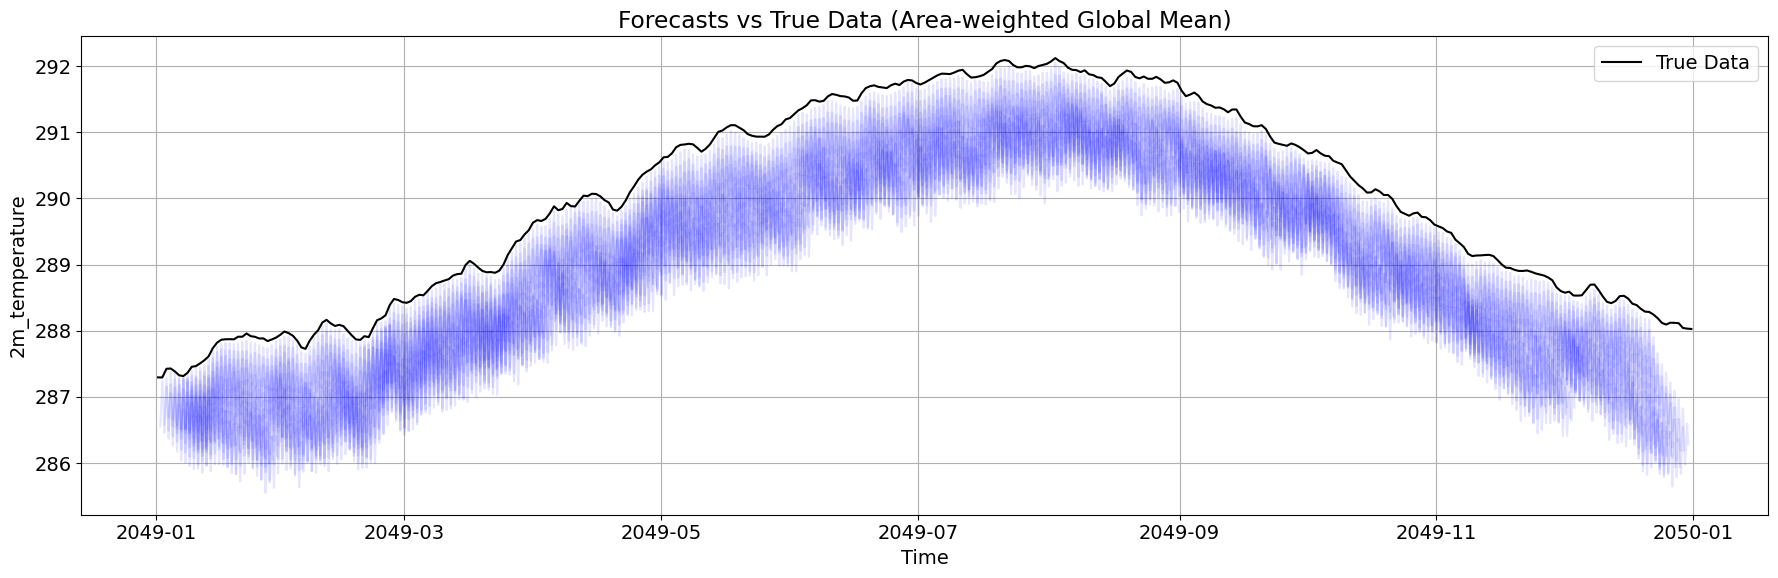

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Load your datasets (if not already in memory)
# original = xr.open_dataset("original_data.nc")
# # forecast = xr.open_dataset("forecast_data.nc")
# dt_nextgems_filtered = dt_nextgems.isel(time=slice(0,200))
# dt_nextgems_prediction_filtered = dt_nextgems_prediction.isel(time=slice(0,100))
dt_nextgems_filtered = dt_nextgems
dt_nextgems_prediction_filtered = dt_nextgems_prediction

# Example variable name
var_name = "2m_temperature"  # change this to your actual variable name

# Prepare weights: cosine of latitude (convert degrees → radians)
weights = np.cos(np.deg2rad(dt_nextgems.latitude))
weights.name = "weights"

# Apply weights to original data
orig_series = (
    dt_nextgems_filtered[var_name]
    #.sel(level=850)
    .weighted(weights)
    .mean(dim=["latitude", "longitude"])
)

# Apply weights to forecast data
forecast_series = (
    dt_nextgems_prediction_filtered[var_name]
    #.sel(level=850)
    .weighted(weights)
    .mean(dim=["latitude", "longitude"])
)

# Subset the original series to only 00 and 12 UTC
orig_series_filtered = orig_series.sel(time=orig_series['time'].dt.hour.isin([12]))
forecast_series_filtered = forecast_series.sel(time=forecast_series['time'].dt.hour.isin([18]))

# Plot original data
plt.figure(figsize=(18, 6))
plt.plot(orig_series_filtered['time'], orig_series_filtered, label="True Data", color="black")

print(forecast_series_filtered)
# Plot forecasts
for init_time in forecast_series_filtered.time.values:
    forecast_times = init_time + forecast_series_filtered.prediction_timedelta.values
    forecast_values = forecast_series_filtered.sel(time=init_time)
    plt.plot(forecast_times, forecast_values, color="blue", alpha=0.1)

plt.xlabel("Time")
plt.ylabel(f"{var_name}")
plt.title(f"Forecasts vs True Data (Area-weighted Global Mean)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [7]:
vis_path = '/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation/plots/'

In [8]:
all_plots = [("Geopotential at 500hPa", "m^2/s^2", "geopotential", 500),
             ("Temperature at 850hPa", "K", "temperature", 850),
             ("Specific humidity at 700hPa", "kg/kg", "specific_humidity", 700),
             ("T2m", "K", "2m_temperature", None),
             ("U-component of wind at 850hPa", "m/s", "u_component_of_wind", 850),
             ("V-component of wind at 850hPa", "m/s", "v_component_of_wind", 850),
             ("Total precipiation (6hr)", "m", "total_precipitation_6hr", None)]

In [22]:
def plot_point_timeseries(lat, lon, lev, color, label):
    # Select the nearest grid point
    
    if lev:
        orig_point = (
            dt_nextgems_filtered[var_name]
            .sel(level=lev)
            .sel(latitude=lat, longitude=lon, method="nearest")
        )

        forecast_point = (
            dt_nextgems_prediction_filtered[var_name]
            .sel(level=lev)
            .sel(latitude=lat, longitude=lon, method="nearest")
        )
    else:
        orig_point = (
            dt_nextgems_filtered[var_name]
            .sel(latitude=lat, longitude=lon, method="nearest")
        )

        forecast_point = (
            dt_nextgems_prediction_filtered[var_name]
            .sel(latitude=lat, longitude=lon, method="nearest")
        )

    # Filter original series to only 00 and 12 UTC
    orig_point_filtered = orig_point.sel(time=orig_point['time'].dt.hour.isin([12]))
    forecast_point_filtered = forecast_point.sel(time=forecast_point['time'].dt.hour.isin([18]))
    plt.plot(orig_point_filtered['time'], orig_point_filtered, color='black')

    step=4  
    first = True
    # Plot forecasts
    for init_time in forecast_point_filtered.time.values:
        forecast_times = init_time + forecast_point_filtered.prediction_timedelta.values[::step]
        forecast_values = forecast_point_filtered.sel(time=init_time).isel(prediction_timedelta=slice(0, None, step))
        if first:
            plt.plot(forecast_times, forecast_values, color=color, alpha=0.4, label=f"Forecast Data – {label}")
            first=False
        else:
            plt.plot(forecast_times, forecast_values, color=color, alpha=0.4)

Temperature max at 850 - conservative
Max temperature: 315.59 K
At indices: time=29950, lon_idx=29, lat_idx=45
At location: lat=38.57142857142857, lon=81.5625, time=2010-07-02T12:00:00.000000000

Temperature max at 850 - mixed
Max temperature: 315.88 K
At indices: time=32946, lon_idx=29, lat_idx=45
At location: lat=38.57142857142857, lon=81.5625, time=2012-07-20T12:00:00.000000000

Temperature max at 2m - mixed
Max temperature: 326.00 K
At indices: time=38814, lon_idx=16, lat_idx=43
At location: lat=32.85714285714286, lon=45.0, time=2016-07-26T12:00:00.000000000

Temperature max at 2m - mixed
Max temperature: 327.24 K
At indices: time=38810, lon_idx=16, lat_idx=43
At location: lat=32.85714285714286, lon=45.0, time=2016-07-25T12:00:00.000000000

In [9]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

# Example grid points (rounded to nearest grid in dataset)
max_850_conservative = (38.57142857142857, 81.5625)
max_850_mixed =(38.57142857142857, 81.5625)
max_2t_conservative = (32.85714285714286, 45.0)
max_2t_mixed = (32.85714285714286, 45.0)
europe_lat, europe_lon = 50, 10    # ~Central Europe
sahara_lat, sahara_lon = 23, 10    # ~Sahara Desert
svalbard_lat, svalbard_lon = 78, 16 # ~Svalbard, Arctic



for (display_name, unit, var_name, level) in all_plots:

    # Plot both locations
    plt.figure(figsize=(20, 8))
    if (conservative):
        plot_point_timeseries(max_850_conservative[0], max_850_conservative[1], level, color="blue", label="Max temp 850hPa")
        plot_point_timeseries(max_2t_conservative[0], max_2t_conservative[1], level, color="red", label="Max temp 2m", )
    else:
        plot_point_timeseries(max_850_mixed[0], max_850_mixed[1], level, color="blue", label="Max temp 850hPa")
        plot_point_timeseries(max_2t_mixed[0], max_2t_mixed[1], level, color="red", label="Max temp 2m", )
    # plot_point_timeseries(sahara_lat, sahara_lon, level, color="orange", label="Sahara")
    # plot_point_timeseries(europe_lat, europe_lon, level, color="red", label="Central Europe", )
    # plot_point_timeseries(svalbard_lat, svalbard_lon, level, color="blue", label="Svalbard (Arctic)")


    plt.xlabel("Time")
    plt.ylabel(f"{display_name} ({unit})")
    plt.title(f"Forecasts vs True Data - {display_name}{f' at {level}' if level else ''}{' - Conservative' if conservative else ''}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig(f"{vis_path}sahara_europe_svalbard/forecast_sahara_europe_svalbard_{var_name}{'_conservative' if conservative else ''}")
    plt.savefig(f"{vis_path}max_temp/forecast_max_temp_{var_name}{'_conservative' if conservative else ''}")


NameError: name 'plot_point_timeseries' is not defined

<Figure size 2000x800 with 0 Axes>

In [16]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

def plot_forecast_vs_truth_hist(var_info, forecast_step, bins=50):
    """
    Plot a histogram comparing ground truth and forecast values at a given level and forecast step.

    Parameters
    ----------
    ground_truth : xr.Dataset
        Dataset containing ground truth data with dimensions (time, longitude, latitude, level).
    forecast : xr.Dataset
        Dataset containing forecast data with dimensions (time, prediction_timedelta, longitude, latitude, level).
    var_name : str
        Variable name (e.g., 't' for temperature).
    level : int
        Pressure level to select (e.g., 850).
    forecast_step : int
        Index of the forecast step in prediction_timedelta (0-based).
    bins : int
        Number of histogram bins.
    """
    (display_name, unit, var_name, level) = var_info
    
    # Select the level
    if level:
        truth_sel = dt_nextgems_filtered[var_name].sel(level=level)
        forecast_sel = dt_nextgems_prediction_filtered[var_name].sel(level=level)
    else:
        truth_sel = dt_nextgems_filtered[var_name]
        forecast_sel = dt_nextgems_prediction_filtered[var_name]

    # Select the forecast lead time by index
    forecast_step_sel = forecast_sel.isel(prediction_timedelta=forecast_step)

    # Flatten into 1D arrays
    truth_values = truth_sel.values.flatten()
    forecast_values = forecast_step_sel.values.flatten()

    # Remove NaNs (just in case)
    truth_values = truth_values[~np.isnan(truth_values)]
    forecast_values = forecast_values[~np.isnan(forecast_values)]

    # Plot histogram
    plt.figure(figsize=(8, 5))
    plt.hist(truth_values, bins=bins, alpha=0.5, label="Ground Truth", density=True)
    plt.hist(forecast_values, bins=bins, alpha=0.5, label=f"Forecast step {forecast_step}", density=True)
    plt.xlabel(f"{display_name}{f' at {level}hPa' if level else ' at surface'}")
    plt.ylabel("Density")
    plt.title(f"Distribution shift after {(forecast_step+1)*6} hours - {display_name}{f' at {level}hPa' if level else ' at surface'}")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{vis_path}distribution_plots/global_distribution_{var_name}{'_conservative' if conservative else ''}_{(forecast_step+1)*6}h")


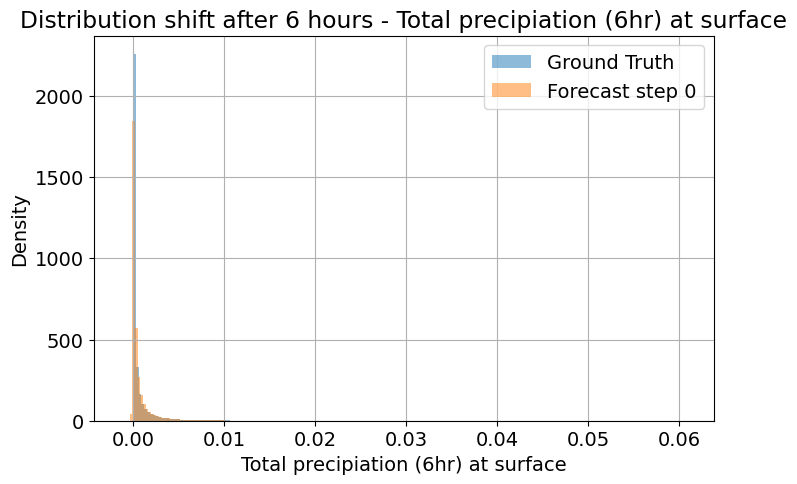

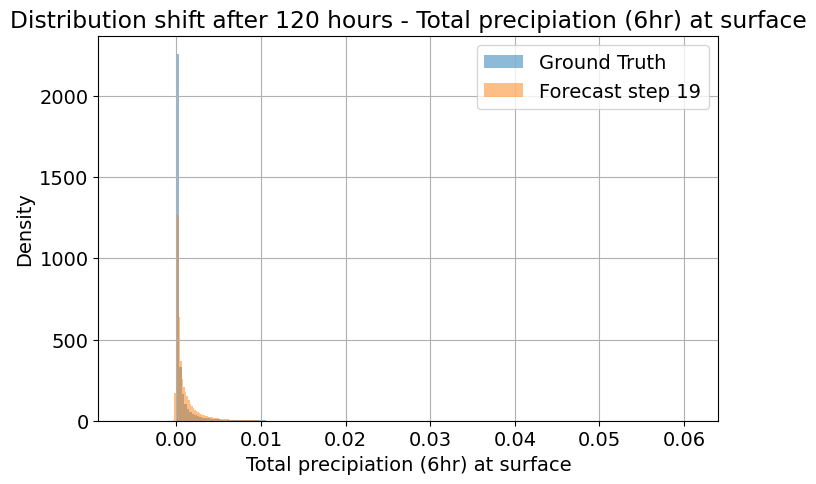

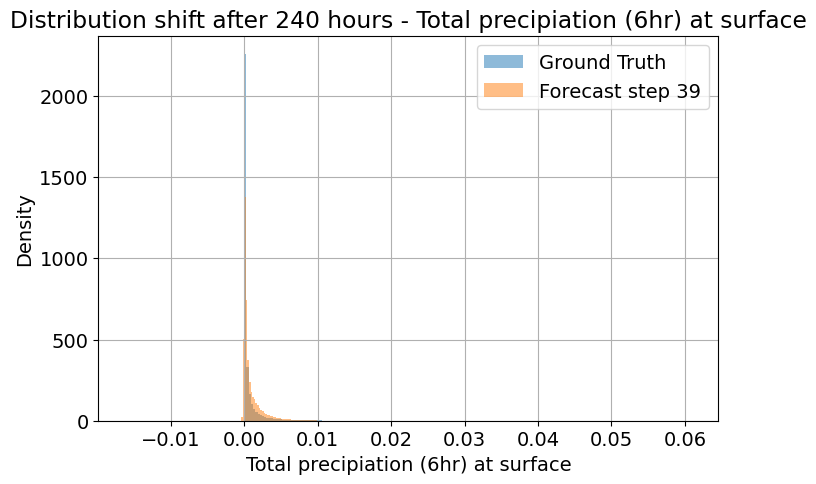

In [17]:
(display_name, unit, var_name, level) = all_plots[-1]
for i in [0, 19, 39]:
    plot_forecast_vs_truth_hist(
        var_info = (display_name, unit, var_name, level),
        forecast_step=i,
        bins=200
    )

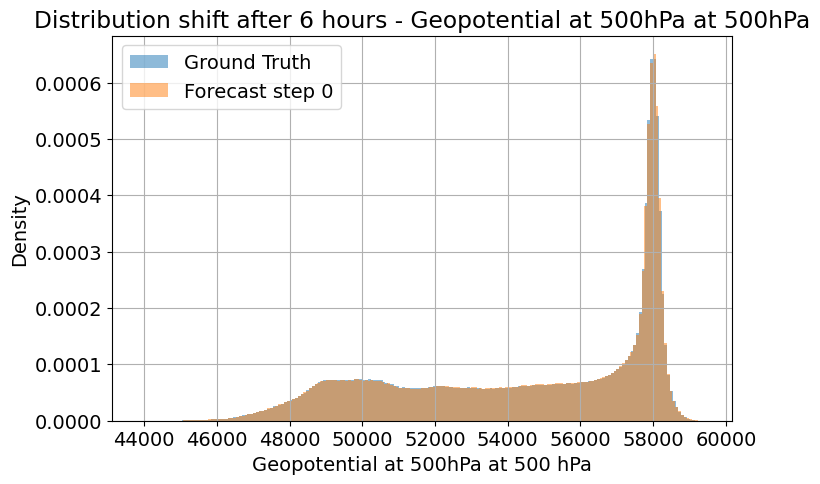

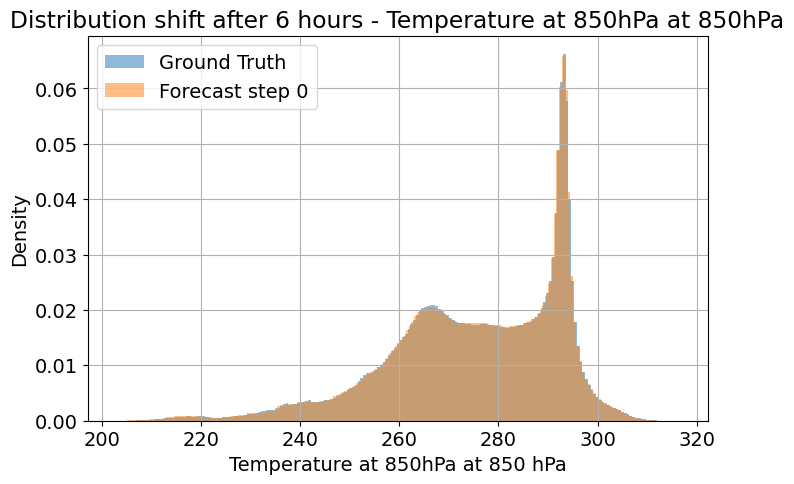

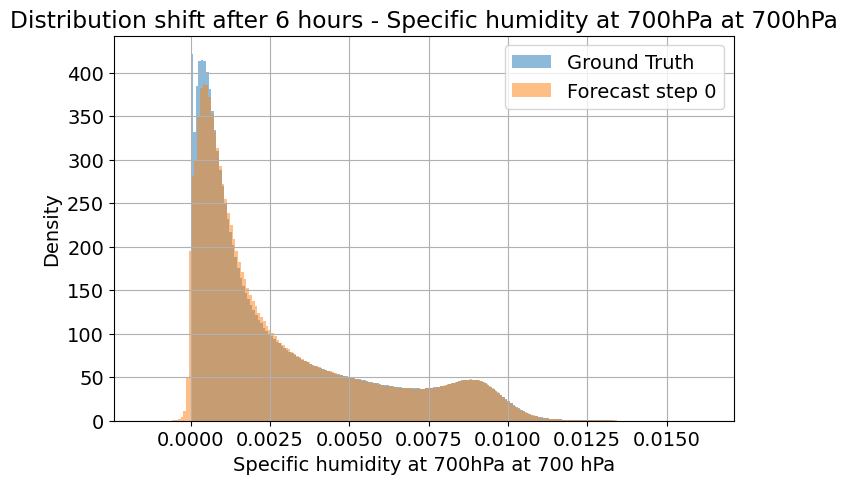

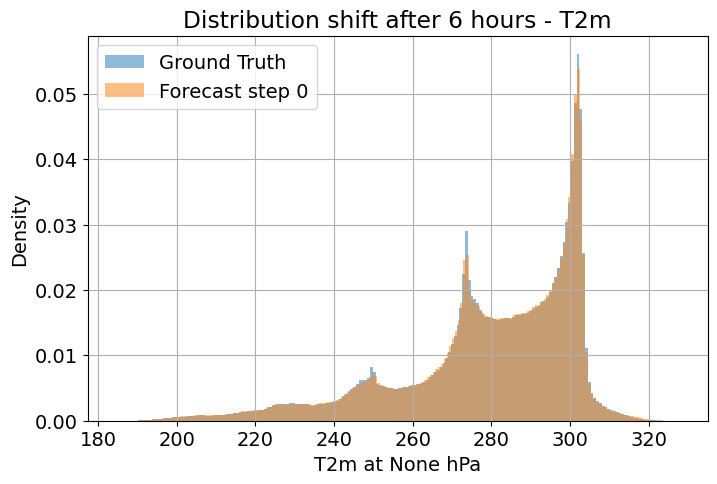

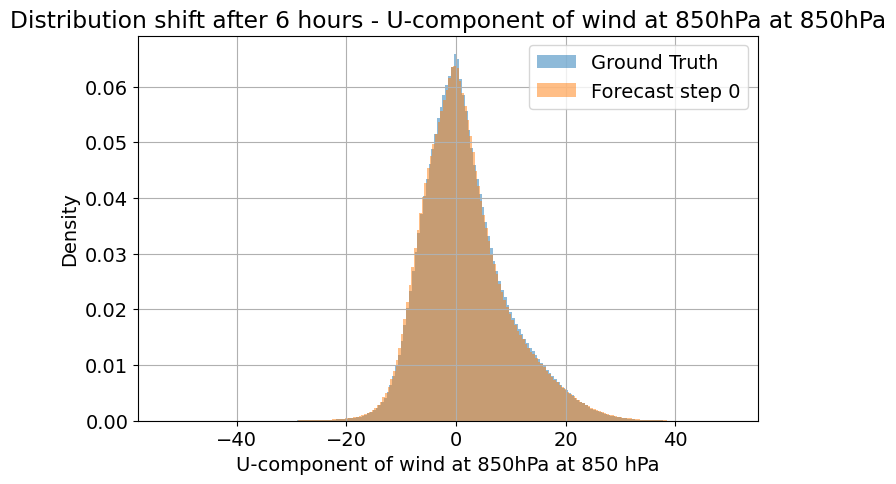

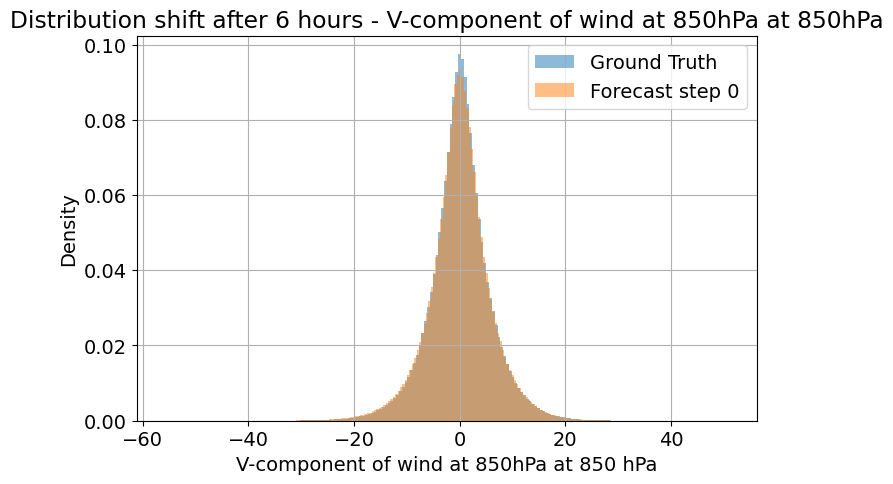

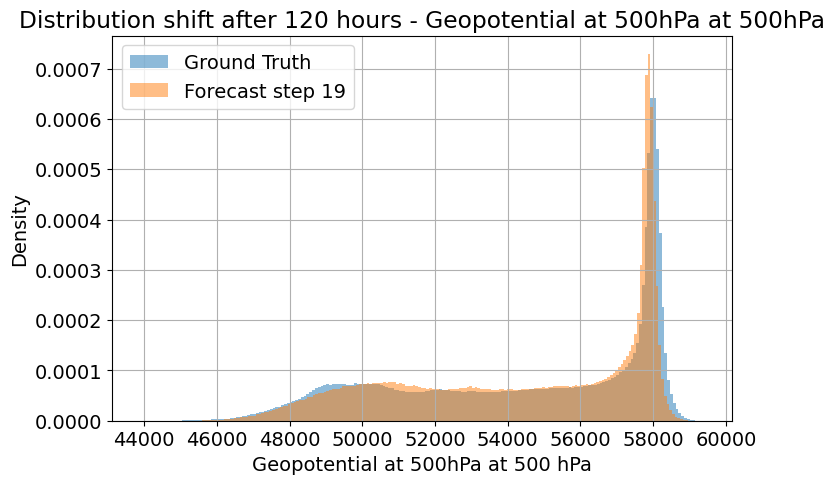

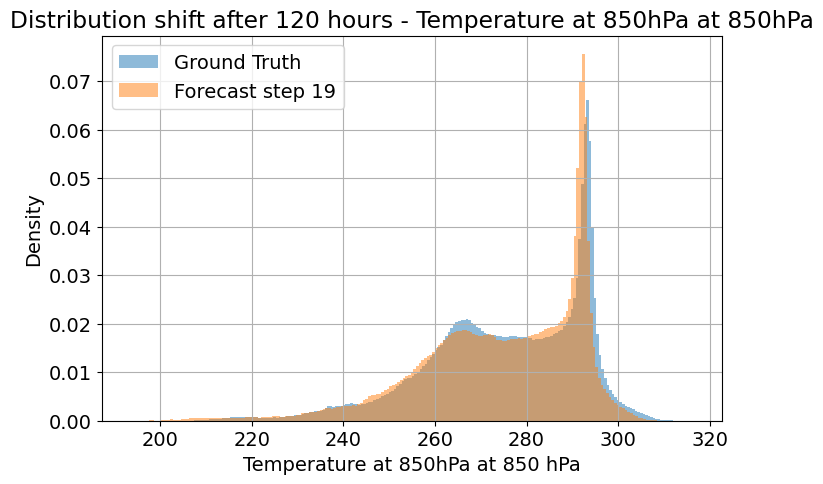

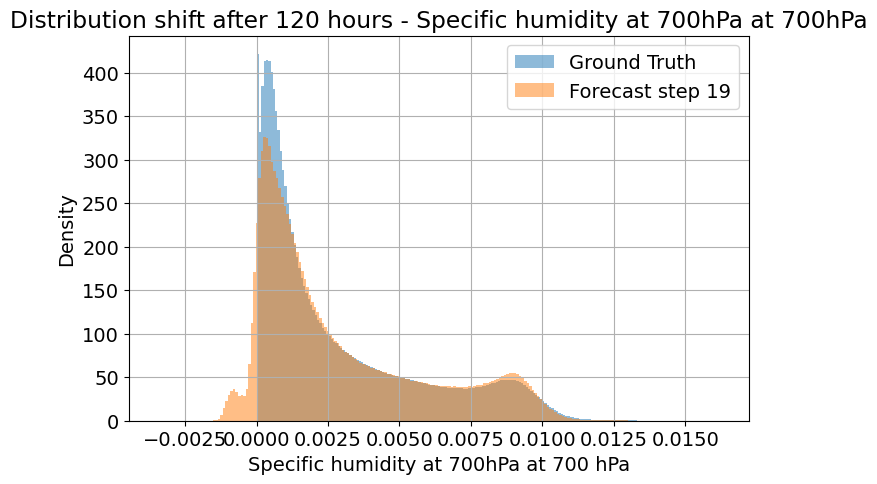

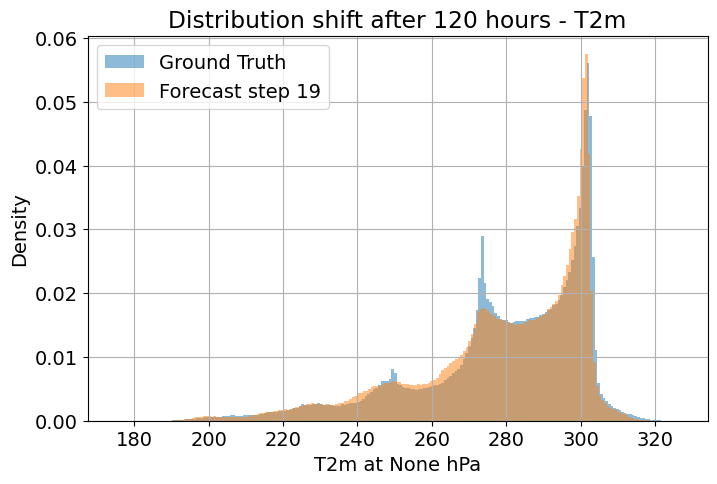

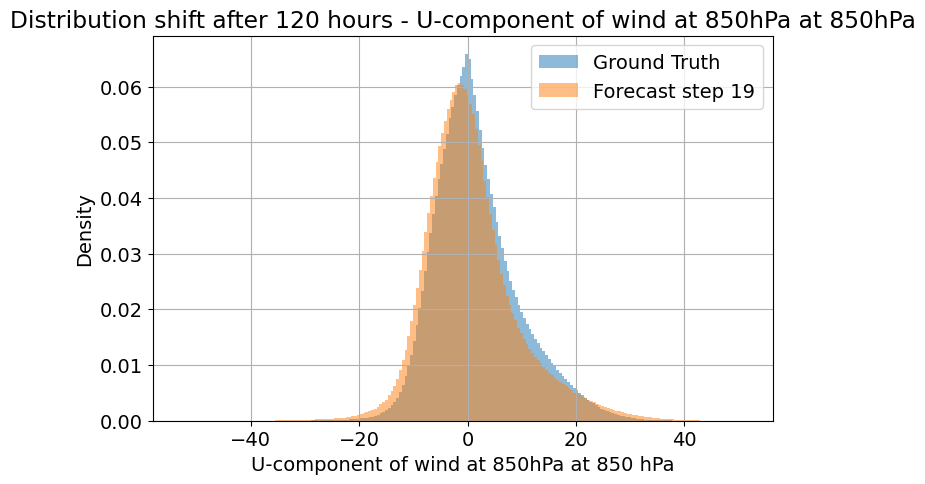

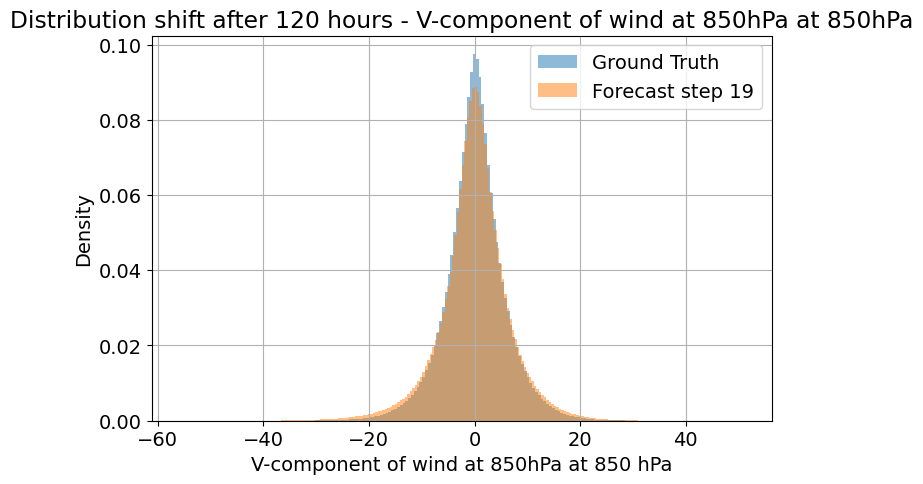

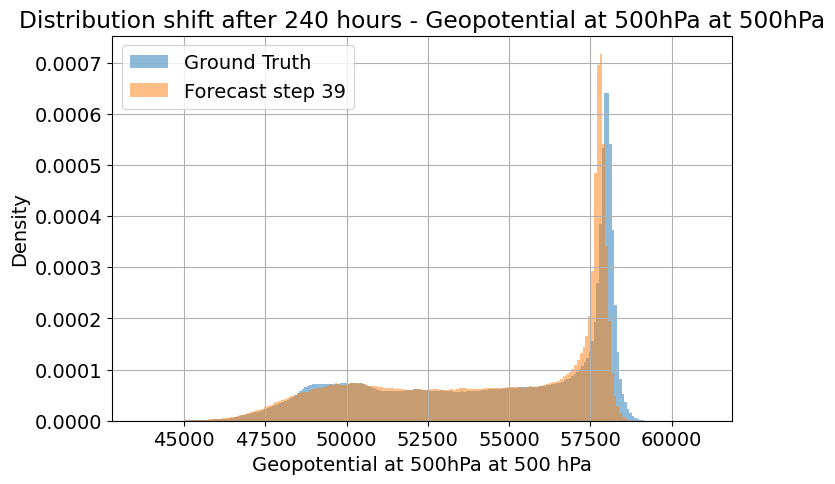

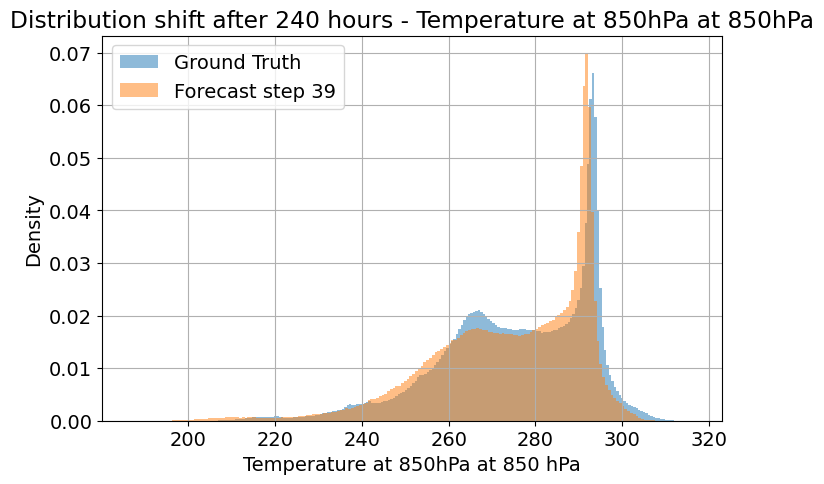

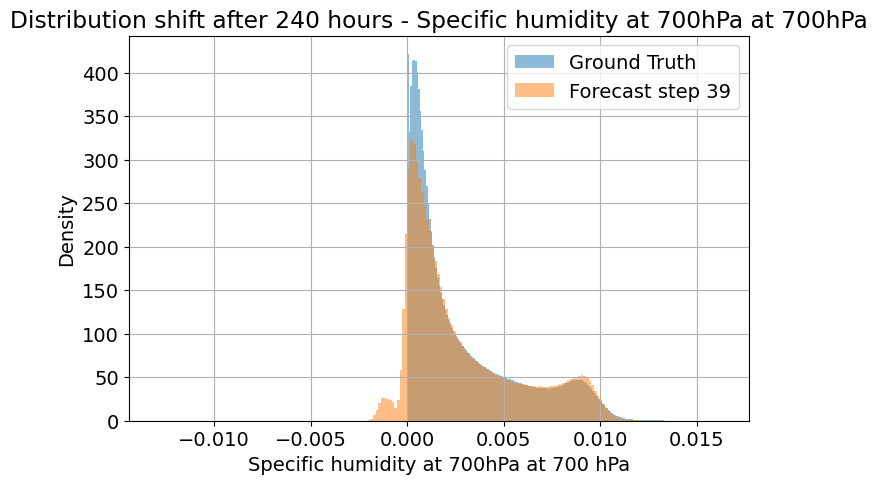

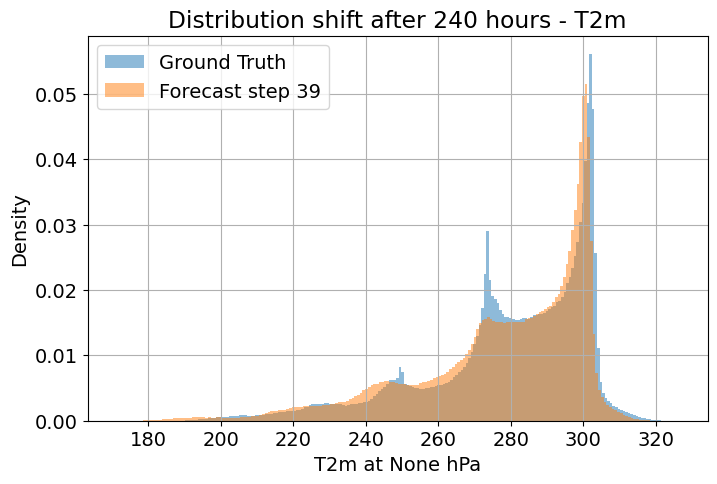

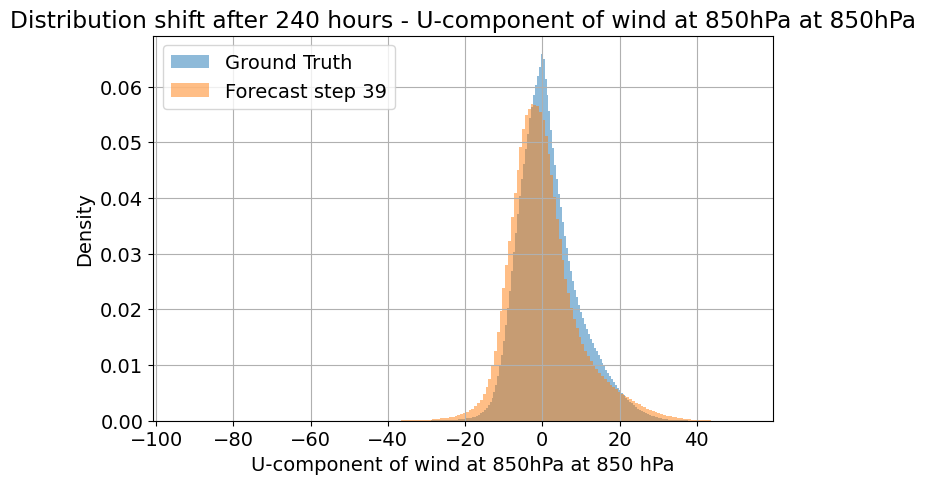

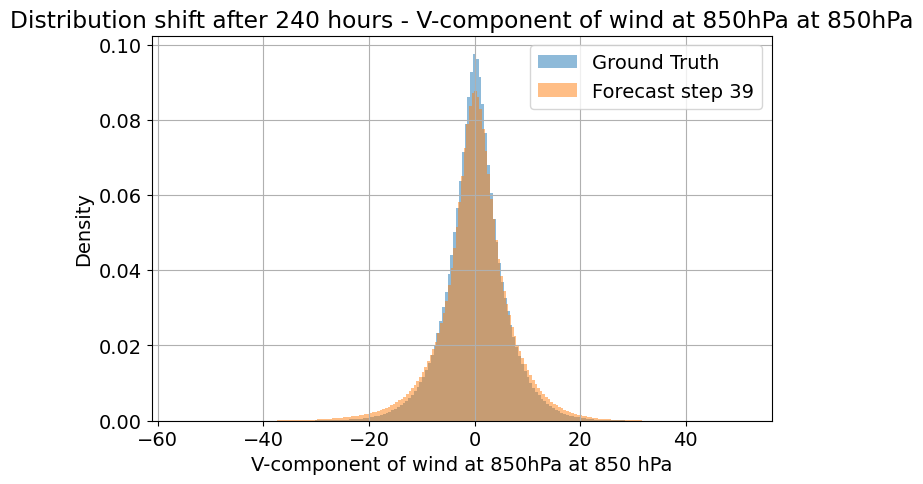

In [ ]:

for i in [0, 19, 39]:
    for (display_name, unit, var_name, level) in all_plots:
        plot_forecast_vs_truth_hist(
            var_info = (display_name, unit, var_name, level),
            forecast_step=i,
            bins=200
        )

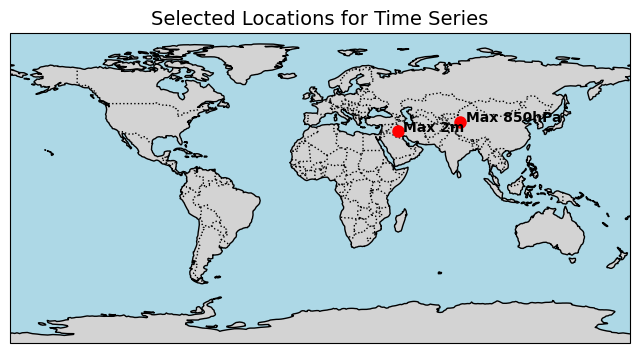

In [21]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

# Location coordinates
locations = {
    "Max 850hPa": max_850_conservative,
    "Max 2m": max_2t_conservative,
}

# Plot map
plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()

# Add map features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.COASTLINE)

# Mark each location
for name, (lat, lon) in locations.items():
    ax.plot(lon, lat, marker="o", color="red", markersize=8, transform=ccrs.PlateCarree())
    ax.text(lon + 3, lat, name, transform=ccrs.PlateCarree(), fontsize=10, weight="bold")

ax.set_title("Selected Locations for Time Series", fontsize=14)

plt.savefig(f"{vis_path}max_temp/map")


<xarray.DataArray 'time' ()> Size: 8B
array('2049-06-27T06:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    level    int64 8B 850
    time     datetime64[ns] 8B 2049-06-27T06:00:00


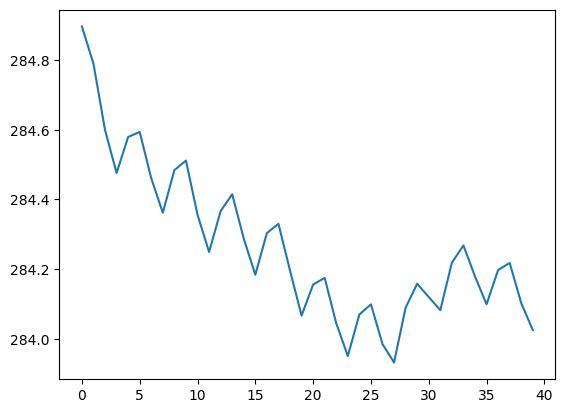

In [9]:
plt.plot(forecast_series[int(len(forecast_series)/2)])
print(forecast_series[int(len(forecast_series)/2)]['time'])

In [3]:
print(ds)
print(ds_2t_conservative)

<xarray.Dataset> Size: 119GB
Dimensions:                  (time: 43828, longitude: 128, latitude: 64,
                              level: 13)
Coordinates:
  * latitude                 (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
  * level                    (level) int64 104B 50 100 150 200 ... 850 925 1000
  * longitude                (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
  * time                     (time) datetime64[ns] 351kB 1990-01-01 ... 2019-...
Data variables: (12/13)
    10m_u_component_of_wind  (time, longitude, latitude) float32 1GB ...
    10m_v_component_of_wind  (time, longitude, latitude) float32 1GB ...
    2m_temperature           (time, longitude, latitude) float32 1GB ...
    geopotential             (time, level, longitude, latitude) float32 19GB ...
    geopotential_at_surface  (longitude, latitude) float32 33kB ...
    land_sea_mask            (longitude, latitude) float32 33kB ...
    ...                       ...
    specific_humidity        

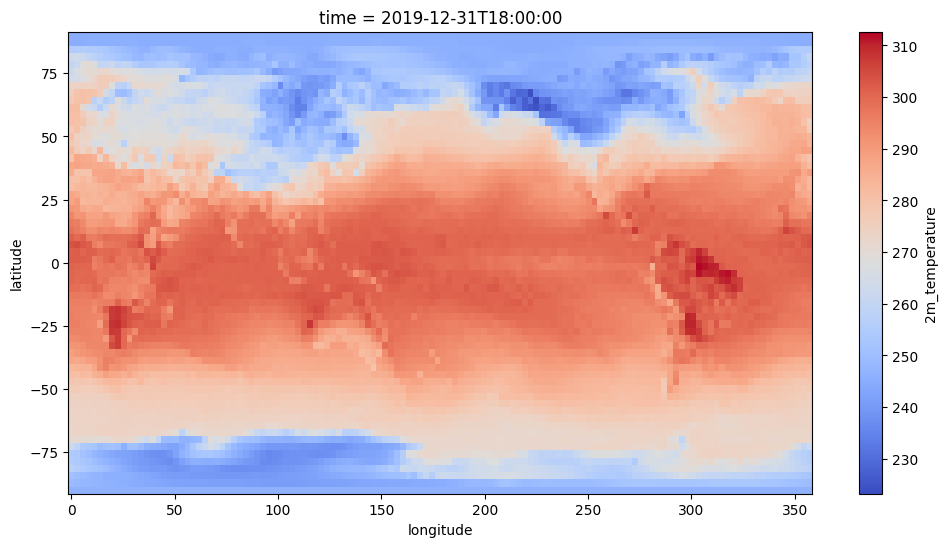

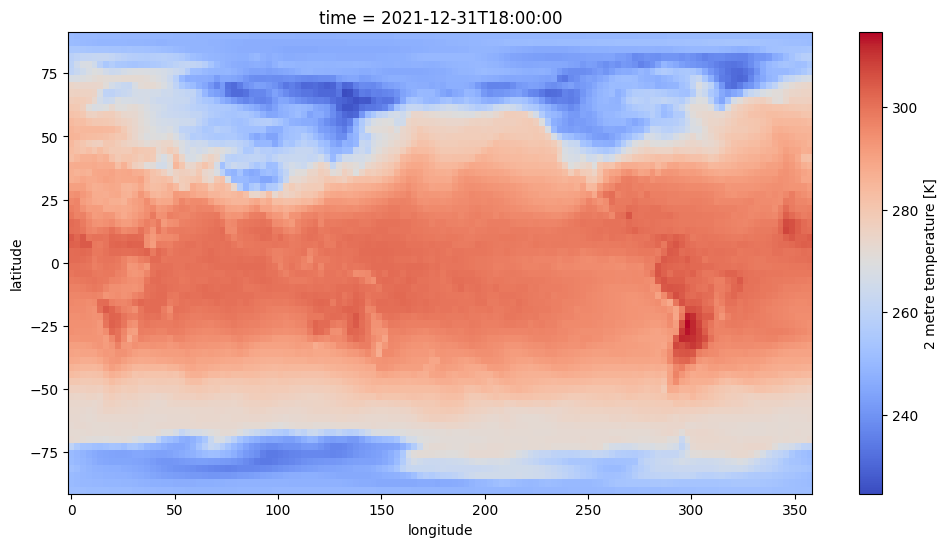

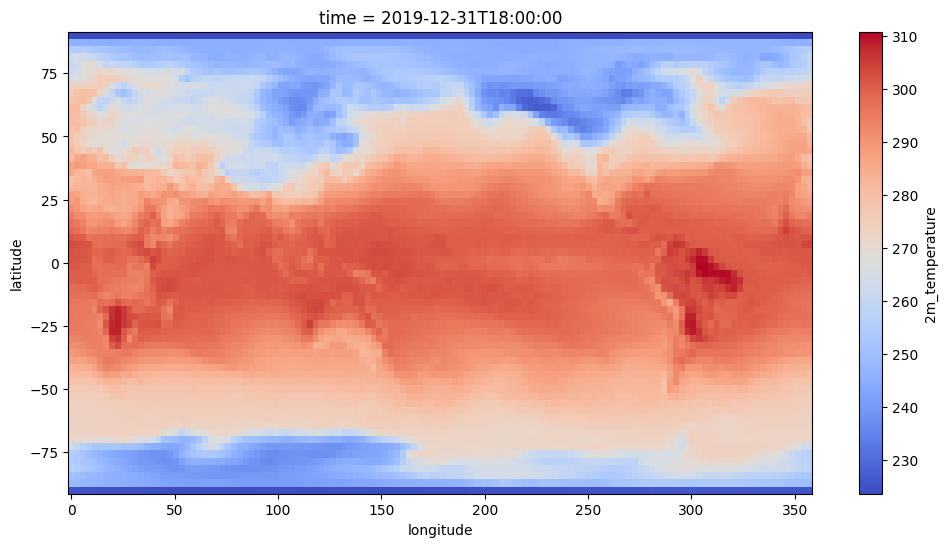

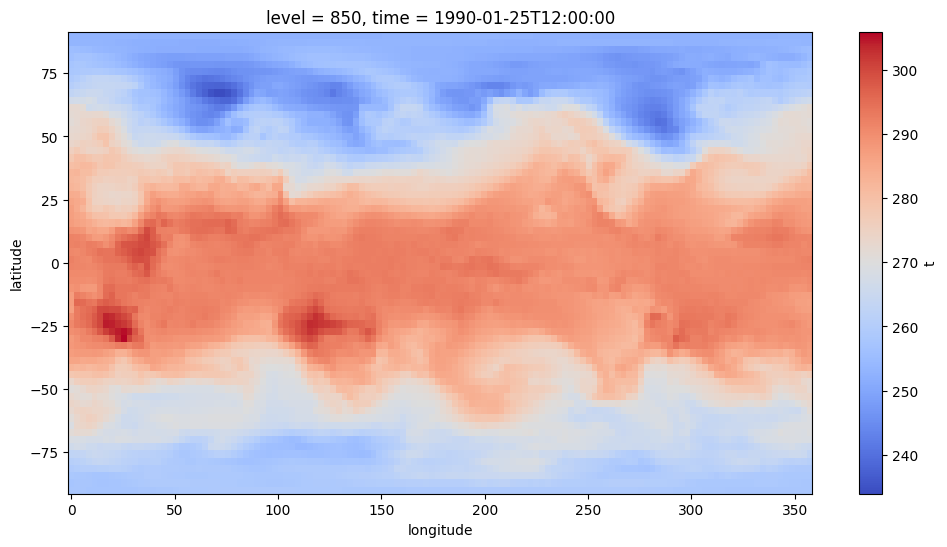

In [3]:
plt.figure(figsize=(12, 6))
ds['2m_temperature'].isel(time=-1).T.plot(cmap='coolwarm')
plt.figure(figsize=(12, 6))
dsera5['2m_temperature'].isel(time=-1).T.plot(cmap='coolwarm')
plt.figure(figsize=(12, 6))
ds_2t_conservative['2m_temperature'].isel(time=-2).T.plot(cmap='coolwarm')
plt.figure(figsize=(12, 6))
dt_try3['t'].sel(level=850).isel(time=-2).T.plot(cmap='coolwarm')

In [22]:
def plot_global_min_temperature(ds, var, var_name):
    """
    Plots the global minimum temperature for each grid point (lat, lon)
    over the entire timespan of the dataset.
    
    Parameters:
        ds (xarray.Dataset): The dataset containing the temperature variable
        var (str): The name of the temperature variable (e.g., '2m_temperature')
    """
    # Compute the minimum temperature at each (lat, lon) over all time
    min_temp = ds[var].min(dim='time')

    # Plot
    plt.figure(figsize=(12, 6))
    min_temp.T.plot(cmap='coolwarm', cbar_kwargs={'label': f'Min {var_name}'})
    plt.title(f'Minimum {var_name} at Each Grid Point (Over Entire Timespan)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.show()


In [23]:
def plot_global_max_temperature(ds, var, var_name):
    """
    Plots the global minimum temperature for each grid point (lat, lon)
    over the entire timespan of the dataset.
    
    Parameters:
        ds (xarray.Dataset): The dataset containing the temperature variable
        var (str): The name of the temperature variable (e.g., '2m_temperature')
    """
    # Compute the minimum temperature at each (lat, lon) over all time
    min_temp = ds[var].max(dim='time')

  # Plot
    plt.figure(figsize=(12, 6))
    min_temp.T.plot(cmap='coolwarm', cbar_kwargs={'label': f'Min {var_name}'})
    plt.title(f'Minimum {var_name} at Each Grid Point (Over Entire Timespan)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True)
    plt.show()


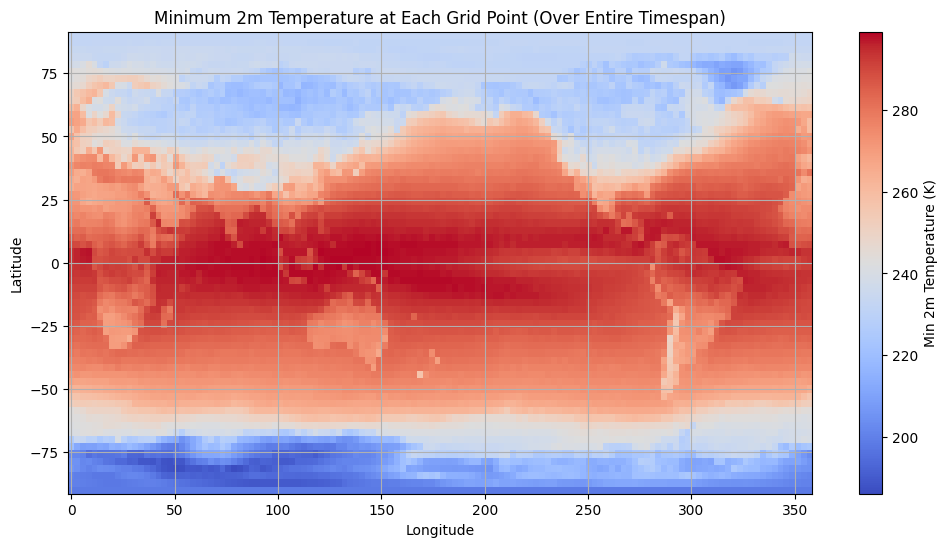

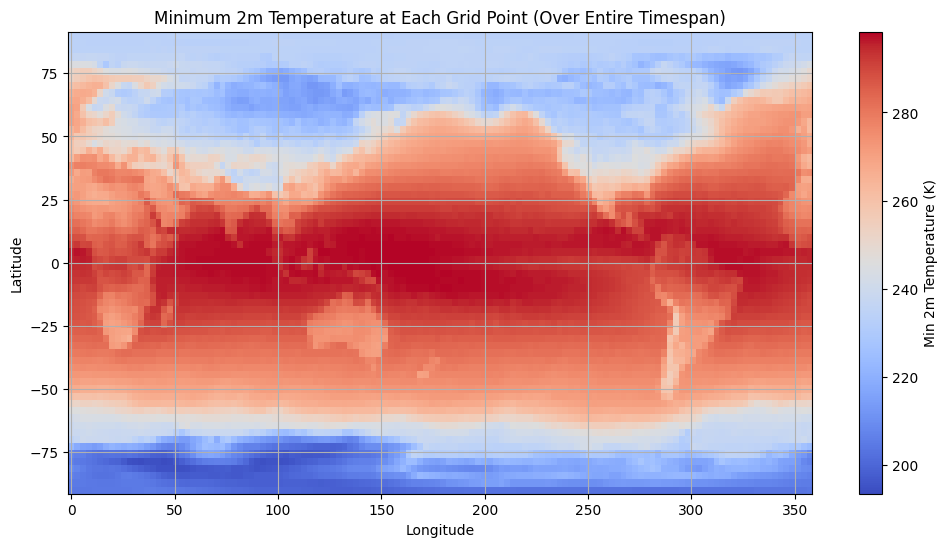

In [ ]:
plot_global_min_temperature(ds, '2m_temperature', '2m Temperature (K)')
plot_global_min_temperature(dsera5, '2m_temperature', '2m Temperature (K)')

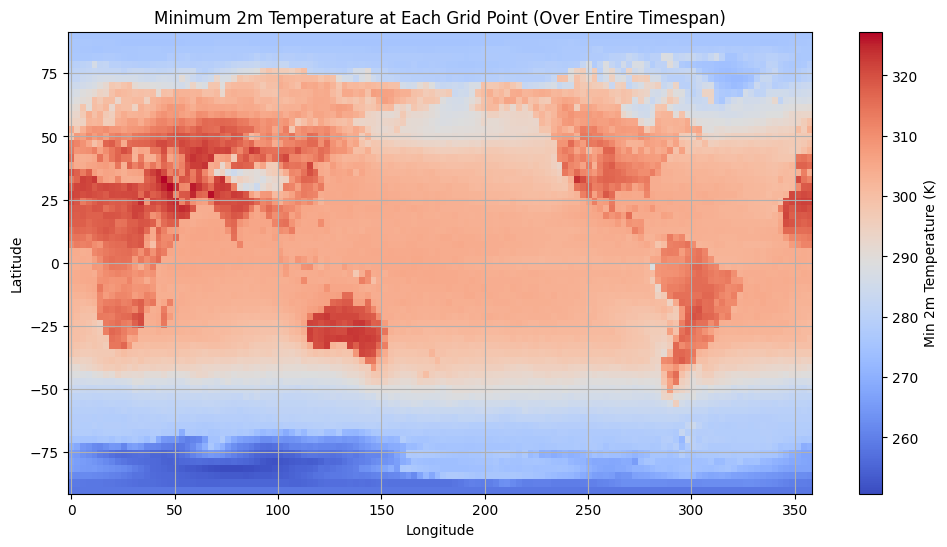

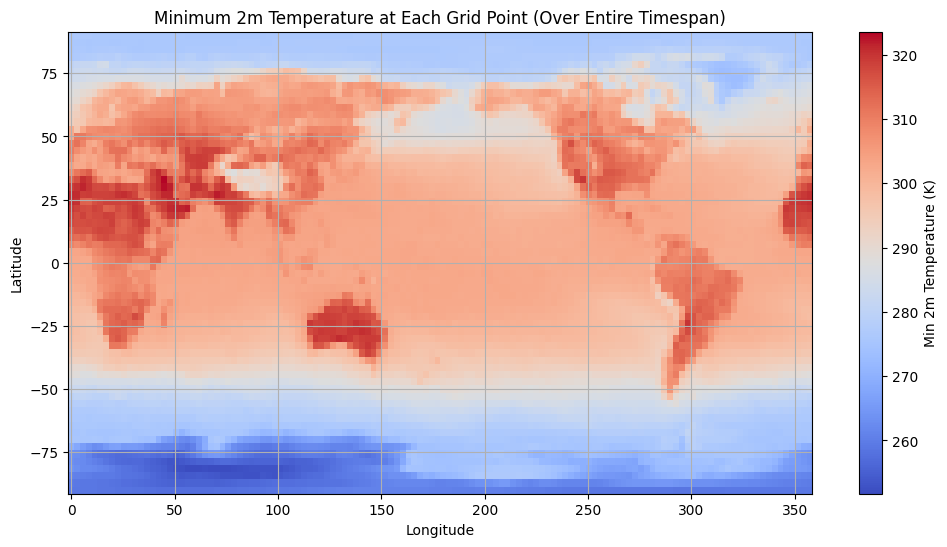

In [ ]:
plot_global_max_temperature(ds, '2m_temperature', '2m Temperature (K)')
plot_global_max_temperature(dsera5, '2m_temperature', '2m Temperature (K)')

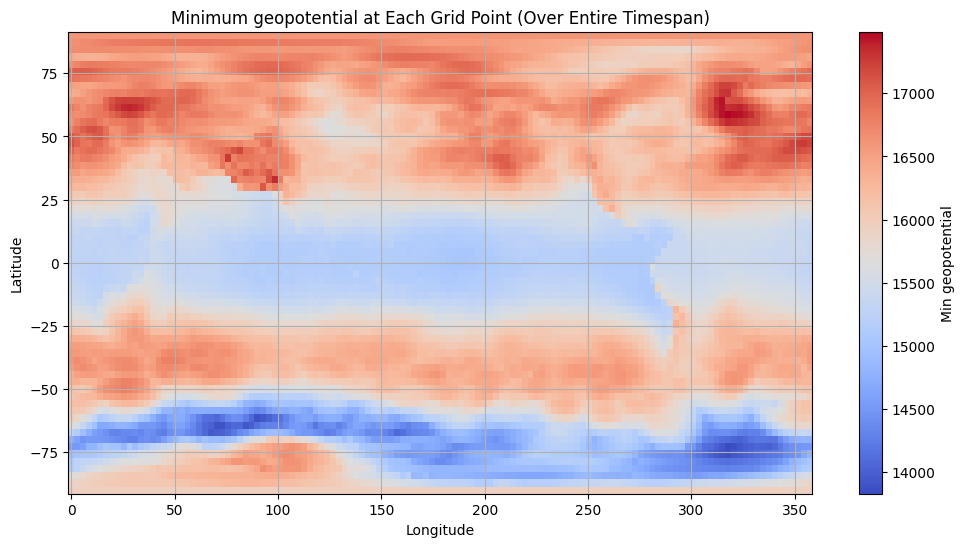

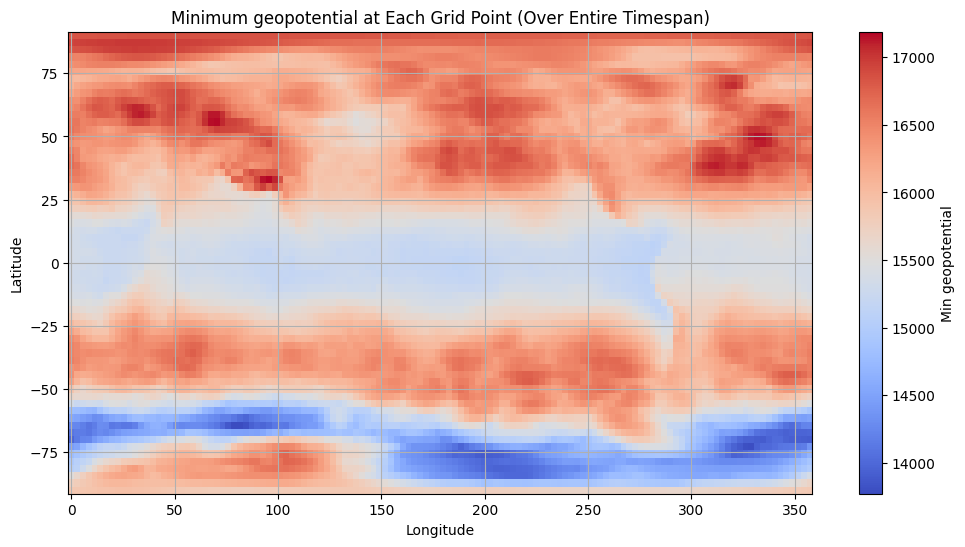

In [26]:
plot_global_max_temperature(ds.sel(level=850), 'geopotential', 'geopotential')
plot_global_max_temperature(dsera5.sel(level=850), 'geopotential', 'geopotential')

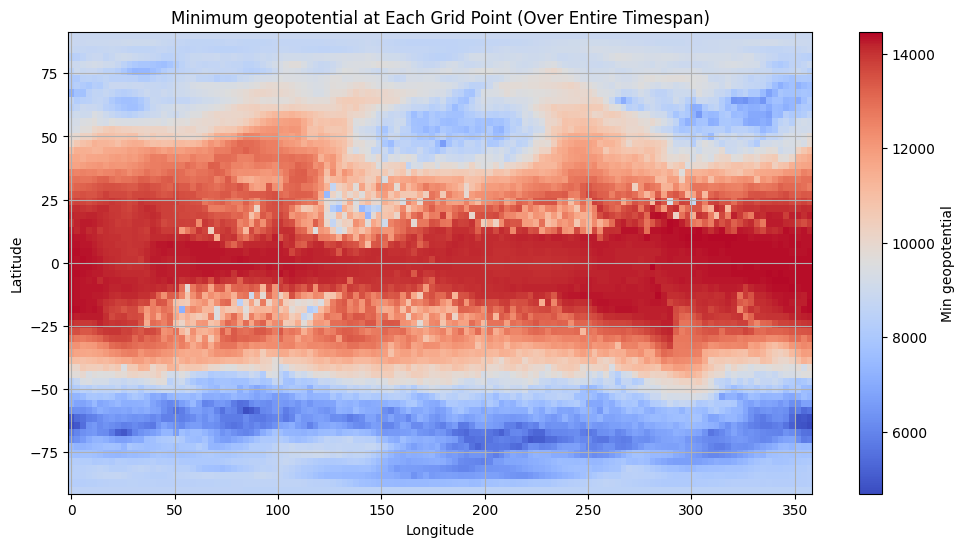

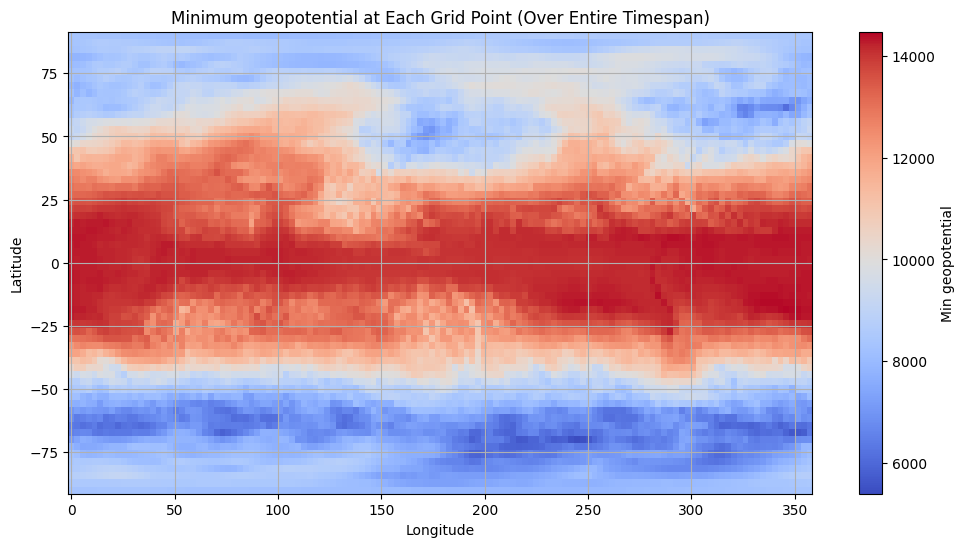

In [27]:
plot_global_min_temperature(ds.sel(level=850), 'geopotential', 'geopotential')
plot_global_min_temperature(dsera5.sel(level=850), 'geopotential', 'geopotential')

In [11]:
ds = xr.open_dataset(base+"global_nextgems_1990_2020_6h-128x64_try2/forcing.zarr")
ds_18_19 = ds.sel(time=ds.time.where((ds.time.dt.year == 2018) | (ds.time.dt.year == 2019), drop=True))

In [12]:
print(ds_18_19)

<xarray.Dataset> Size: 478MB
Dimensions:                        (time: 2920, longitude: 128, latitude: 64,
                                    forcing_var: 5)
Coordinates:
  * forcing_var                    (forcing_var) object 40B 'toa_incident_rad...
  * latitude                       (latitude) float64 512B -90.0 -87.14 ... 90.0
  * longitude                      (longitude) float64 1kB 0.0 2.812 ... 357.2
  * time                           (time) datetime64[ns] 23kB 2018-01-01 ... ...
Data variables:
    __xarray_dataarray_variable__  (time, longitude, latitude, forcing_var) float32 478MB ...


In [13]:
ds_18_19.to_zarr("/hkfs/work/workspace/scratch/xo8179-neural_lam/data/data/global_nextgems_1990_2020_6h-128x64_eval_runs/perturbation/forcing.zarr", mode='w')

TypeError: expected unicode string, found 5